    invoice_id branch       city customer_type gender_customer  \
0  750-67-8428      A     Yangon        Member          Female   
1  226-31-3081      C  Naypyitaw        Normal          Female   
2  631-41-3108      A     Yangon        Normal            Male   
3  123-19-1176      A     Yangon        Member            Male   
4  373-73-7910      A     Yangon        Normal            Male   
5  699-14-3026      C  Naypyitaw        Normal            Male   
6  355-53-5943      A     Yangon        Member          Female   
7  315-22-5665      C  Naypyitaw        Normal          Female   
8  665-32-9167      A     Yangon        Member          Female   
9  692-92-5582      B   Mandalay        Member          Female   

             product_line  unit_cost  quantity  5pct_markup   revenue  \
0       Health and beauty      74.69         7      26.1415  548.9715   
1  Electronic accessories      15.28         5       3.8200   80.2200   
2      Home and lifestyle      46.33         7      16

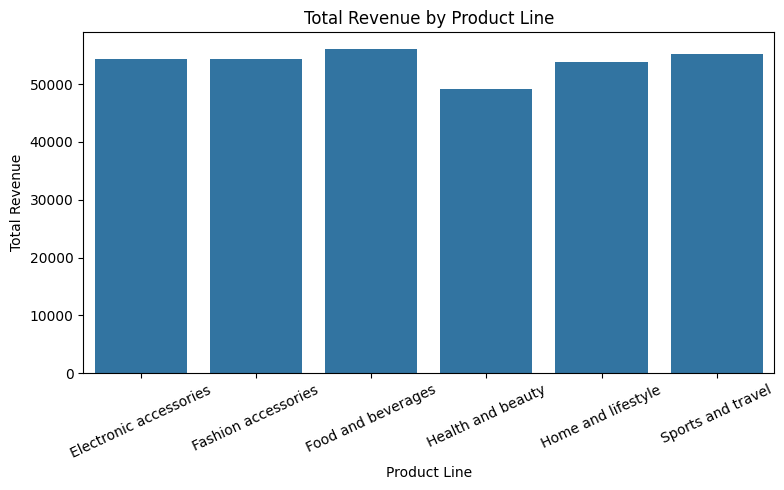

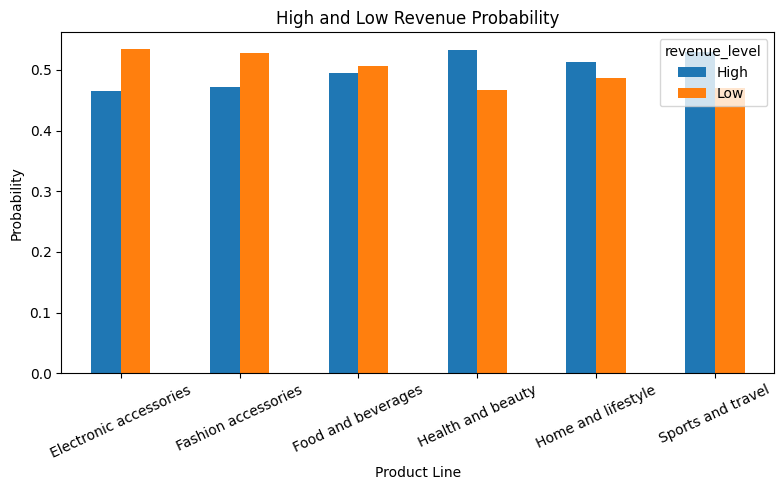


Highest High-Revenue Probability:
Product Line: Health and beauty
Probability: 0.5329

Lavkush T048


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# STEP 1: LOAD THE DATASET
data = pd.read_csv("supermarket_sales.csv")
print(data.head(10))

# STEP 2: EXPLORE THE DATASET
print("\nNumber of Records:", data.shape[0])
print("Number of Columns:", data.shape[1])
print("\nColumn Names:")
print(data.columns)
print("\nData Types:")
print(data.dtypes)

# STEP 3: DISPLAY UNIQUE PRODUCT LINES
print("\nUnique Product Lines:")
print(data["product_line"].unique())

# STEP 4: TOTAL REVENUE BY PRODUCT LINE
print("\nTotal Revenue by Product Line:")
print(data.groupby("product_line")["revenue"].sum())

# STEP 5: AVERAGE REVENUE BY PRODUCT LINE
print("\nAverage Revenue by Product Line:")
print(data.groupby("product_line")["revenue"].mean())

# STEP 6: TOTAL QUANTITY SOLD
print("\nTotal Quantity Sold:")
print(data["quantity"].sum())

# STEP 7: MEDIAN REVENUE
median_revenue = data["revenue"].median()
print("\nMedian Revenue:")
print(median_revenue)

# STEP 8: CLASSIFY TRANSACTIONS AS HIGH OR LOW
data["revenue_level"] = data["revenue"].apply(
    lambda x: "High" if x >= median_revenue else "Low"
)

# STEP 9: DISPLAY REVENUE LEVEL
print("\nRevenue Level:")
print(
    data[
        ["product_line", "revenue", "revenue_level"]
    ].head(10)
)

# STEP 10: COUNT HIGH AND LOW REVENUE BY PRODUCT LINE
print("\nRevenue Level Count by Product Line:")
print(
    pd.crosstab(
        data["product_line"],
        data["revenue_level"]
    )
)

# STEP 11: CALCULATE PROBABILITIES
probability = pd.crosstab(
    data["product_line"],
    data["revenue_level"],
    normalize="index"
)
print("\nProbability of Revenue Level:")
print(probability)

# STEP 12: VERIFY PROBABILITIES
print("\nSum of Probabilities:")
print(probability.sum(axis=1))

# STEP 13: AVERAGE REVENUE FOR HIGH AND LOW LEVELS
print("\nAverage Revenue by Product Line and Revenue Level:")
print(
    data.groupby(
        ["product_line", "revenue_level"],
        observed=True
    )["revenue"].mean()
)

# STEP 14: CREATE DECISION TABLE
decision_table = probability.reset_index().melt(
    id_vars="product_line",
    var_name="Revenue Level",
    value_name="Probability"
)
payoff = data.groupby(
    ["product_line", "revenue_level"],
    observed=True
)["revenue"].mean().reset_index()
payoff.columns = [
    "product_line",
    "Revenue Level",
    "Payoff"
]
decision_table = decision_table.merge(
    payoff,
    on=["product_line", "Revenue Level"]
)
print("\nDecision Table:")
print(decision_table)

# STEP 15: DISPLAY DECISION ALTERNATIVES
print("\nDecision Alternatives:")
print(data["product_line"].unique())

# DISPLAY UNCERTAIN OUTCOMES
print("\nUncertain Outcomes:")
print(data["revenue_level"].unique())

# STEP 16: CONSTRUCT DECISION TREE
print("\nDecision Tree:")
for product in data["product_line"].unique():
    print("\nProduct Line:", product)
    print(
        "  High Revenue -> Probability:",
        round(probability.loc[product, "High"], 4)
    )
    print(
        "  Low Revenue  -> Probability:",
        round(probability.loc[product, "Low"], 4)
    )

# STEP 17: DISPLAY PROBABILITY AND PAYOFF
print("\nProbability and Payoff:")
print(decision_table)

# STEP 18: TOTAL REVENUE VISUALIZATION
revenue = data.groupby("product_line")["revenue"].sum()
plt.figure(figsize=(8, 5))
sns.barplot(
    x=revenue.index,
    y=revenue.values
)
plt.title("Total Revenue by Product Line")
plt.xlabel("Product Line")
plt.ylabel("Total Revenue")
plt.xticks(rotation=25)
plt.tight_layout()
plt.show()

# STEP 19: PROBABILITY VISUALIZATION
probability.plot(
    kind="bar",
    figsize=(8, 5)
)
plt.title("High and Low Revenue Probability")
plt.xlabel("Product Line")
plt.ylabel("Probability")
plt.xticks(rotation=25)
plt.tight_layout()
plt.show()

# STEP 20: HIGHEST HIGH-REVENUE PROBABILITY
best_product = probability["High"].idxmax()
best_probability = probability["High"].max()
print("\nHighest High-Revenue Probability:")
print("Product Line:", best_product)
print(
    "Probability:",
    round(best_probability, 4)
)

# STUDENT DETAILS
print("\nLavkush T048")


23-24. Expected Value for Every Product Line:
product_line
Electronic accessories    319.63
Fashion accessories       305.09
Food and beverages        322.67
Health and beauty         323.64
Home and lifestyle        336.64
Sports and travel         332.07
Name: Weighted Payoff, dtype: float64

25. Expected Value DataFrame:
             Product Line  High Revenue Probability  High Revenue Payoff  \
0  Electronic accessories                      0.46               537.01   
1     Fashion accessories                      0.47               512.33   
2      Food and beverages                      0.49               515.13   
3       Health and beauty                      0.53               497.22   
4      Home and lifestyle                      0.51               529.58   
5       Sports and travel                      0.53               518.55   

   Low Revenue Probability  Low Revenue Payoff  Expected Value  
0                     0.54              130.92          319.63  
1         

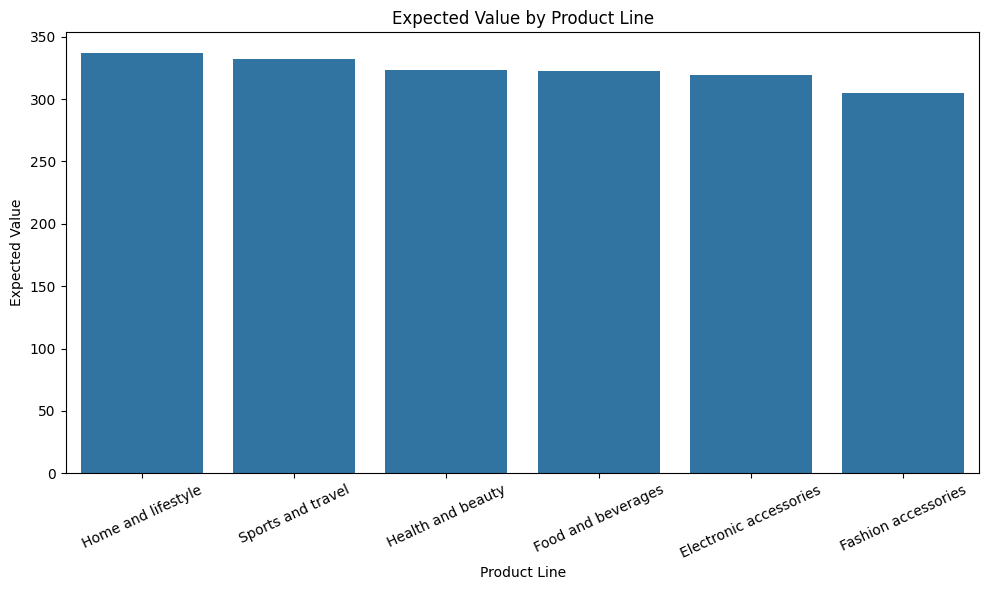


31. Highest Probability of High Revenue:
Product Line: Health and beauty
Probability: 0.5329
Highest Expected Value Product Line: Home and lifestyle

32. No, they are different product lines.

33. Change in Probability:
Product Line: Electronic accessories
Original Expected Value: 319.63
New Expected Value: 360.24

34. Change in Payoff:
Product Line: Electronic accessories
Original Expected Value: 319.63
New Expected Value: 344.59

35. Automatically Selected Product Line:
Home and lifestyle
Expected Value: 336.64

36. Final Decision Tree:

Decision: Electronic accessories
  High Revenue
    Probability: 0.4647
    Payoff: 537.01
  Low Revenue
    Probability: 0.5353
    Payoff: 130.92
  Expected Value: 319.63

Decision: Fashion accessories
  High Revenue
    Probability: 0.4719
    Payoff: 512.33
  Low Revenue
    Probability: 0.5281
    Payoff: 119.9
  Expected Value: 305.09

Decision: Food and beverages
  High Revenue
    Probability: 0.4943
    Payoff: 515.13
  Low Revenue
    Prob

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 23 & 24. Calculate Expected Value
ev_table = decision_table.copy()
ev_table["Weighted Payoff"] = ev_table["Probability"] * ev_table["Payoff"]
expected_value = ev_table.groupby("product_line")["Weighted Payoff"].sum()
print("\n23-24. Expected Value for Every Product Line:")
print(expected_value.round(2))

# 25. Create Expected Value DataFrame
high_probability = probability["High"]
low_probability = probability["Low"]
high_payoff = data[data["revenue_level"] == "High"].groupby("product_line")["revenue"].mean()
low_payoff = data[data["revenue_level"] == "Low"].groupby("product_line")["revenue"].mean()
ev_dataframe = pd.DataFrame({
    "Product Line": expected_value.index,
    "High Revenue Probability": high_probability.values,
    "High Revenue Payoff": high_payoff.values,
    "Low Revenue Probability": low_probability.values,
    "Low Revenue Payoff": low_payoff.values,
    "Expected Value": expected_value.values})
print("\n25. Expected Value DataFrame:")
print(ev_dataframe.round(2))

# 26. Compare Expected Values
comparison = ev_dataframe[["Product Line", "Expected Value"]].sort_values(
    by="Expected Value", ascending=False)
print("\n26. Comparison of Expected Values:")
print(comparison.round(2))

# 27. Highest Expected Value
highest_ev_product = expected_value.idxmax()
highest_ev = expected_value.max()
print("\n27. Highest Expected Value:")
print("Product Line:", highest_ev_product)
print("Expected Value:", round(highest_ev, 2))

# 28. Lowest Expected Value
lowest_ev_product = expected_value.idxmin()
lowest_ev = expected_value.min()
print("\n28. Lowest Expected Value:")
print("Product Line:", lowest_ev_product)
print("Expected Value:", round(lowest_ev, 2))

# 29. Rank Product Lines
ranking = ev_dataframe[["Product Line", "Expected Value"]].sort_values(
    by="Expected Value", ascending=False
).reset_index(drop=True)
ranking["Rank"] = ranking.index + 1
ranking = ranking[["Rank", "Product Line", "Expected Value"]]
print("\n29. Product Line Ranking:")
print(ranking.round(2))

# 30. Expected Value Bar Chart
plt.figure(figsize=(10, 6))
sns.barplot(
    data=ev_dataframe.sort_values("Expected Value", ascending=False),
    x="Product Line",
    y="Expected Value")
plt.title("Expected Value by Product Line")
plt.xlabel("Product Line")
plt.ylabel("Expected Value")
plt.xticks(rotation=25)
plt.tight_layout()
plt.show()

# 31. Compare Highest Probability with Highest Expected Value
highest_probability_product = probability["High"].idxmax()
highest_probability = probability["High"].max()
print("\n31. Highest Probability of High Revenue:")
print("Product Line:", highest_probability_product)
print("Probability:", round(highest_probability, 4))
print("Highest Expected Value Product Line:", highest_ev_product)

# 32. Check Whether They Are the Same
if highest_probability_product == highest_ev_product:
    print("\n32. Yes, both are the same product line.")
else:
    print("\n32. No, they are different product lines.")

# 33. Change Probability
test_product = ev_dataframe["Product Line"].iloc[0]
row = ev_dataframe[ev_dataframe["Product Line"] == test_product].iloc[0]
original_high_probability = row["High Revenue Probability"]
original_low_probability = row["Low Revenue Probability"]
high_payoff_value = row["High Revenue Payoff"]
low_payoff_value = row["Low Revenue Payoff"]
new_high_probability = min(original_high_probability + 0.10, 1)
new_low_probability = 1 - new_high_probability
original_ev = (
    original_high_probability * high_payoff_value +
    original_low_probability * low_payoff_value)
new_ev_probability = (
    new_high_probability * high_payoff_value +
    new_low_probability * low_payoff_value)
print("\n33. Change in Probability:")
print("Product Line:", test_product)
print("Original Expected Value:", round(original_ev, 2))
print("New Expected Value:", round(new_ev_probability, 2))

# 34. Change Payoff
new_high_payoff = high_payoff_value * 1.10

new_ev_payoff = (
    original_high_probability * new_high_payoff +
    original_low_probability * low_payoff_value
)
print("\n34. Change in Payoff:")
print("Product Line:", test_product)
print("Original Expected Value:", round(original_ev, 2))
print("New Expected Value:", round(new_ev_payoff, 2))

# 35. Automatic Expected Value Calculation
ev_dataframe["Calculated EV"] = (
    ev_dataframe["High Revenue Probability"] *
    ev_dataframe["High Revenue Payoff"] +
    ev_dataframe["Low Revenue Probability"] *
    ev_dataframe["Low Revenue Payoff"]
)
best_row = ev_dataframe.sort_values(
    "Calculated EV",
    ascending=False
).iloc[0]
selected_product = best_row["Product Line"]
selected_ev = best_row["Calculated EV"]
print("\n35. Automatically Selected Product Line:")
print(selected_product)
print("Expected Value:", round(selected_ev, 2))

# 36. Final Decision Tree
print("\n36. Final Decision Tree:")
for product in ev_dataframe["Product Line"]:
    row = ev_dataframe[ev_dataframe["Product Line"] == product].iloc[0]
    print("\nDecision:", product)
    print("  High Revenue")
    print("    Probability:", round(row["High Revenue Probability"], 4))
    print("    Payoff:", round(row["High Revenue Payoff"], 2))
    print("  Low Revenue")
    print("    Probability:", round(row["Low Revenue Probability"], 4))
    print("    Payoff:", round(row["Low Revenue Payoff"], 2))
    print("  Expected Value:", round(row["Calculated EV"], 2))

# 37. Business Recommendation
print("\n37. Business Recommendation:")
print(
    f"Based on Expected Value, {selected_product} has the highest "
    f"Expected Value of {selected_ev:.2f}."
)
print("Therefore, it can be selected based on the Expected Value analysis.")
print("\nLavkush T048")